# Iteración V2: Double DQN

En esta iteración se implementa Double DQN utilizando la misma arquitectura convolucional y los mismos hiperparámetros principales del DQN vanilla.

En DQN vanilla, la red objetivo selecciona y evalúa la acción futura mediante:

$$
y = r + \gamma(1-d)\max_{a'}Q_{\text{target}}(s',a')
$$

Double DQN separa ambas responsabilidades:

1. La red online selecciona la acción con mayor valor estimado:

$$
a^* = \arg\max_{a'}Q_{\text{online}}(s',a')
$$

2. La red target evalúa la acción seleccionada:

$$
y = r + \gamma(1-d)Q_{\text{target}}(s',a^*)
$$

Esta modificación no cambia la arquitectura de la CNN. Solamente cambia la manera en que se calcula el target durante el entrenamiento.

El objetivo de esta iteración es determinar si Double DQN:

- Reduce la sobreestimación de los valores Q.
- Produce evaluaciones más estables.
- Supera el promedio de 406.67 puntos obtenido por DQN vanilla.
- Obtiene un mejor resultado bajo el criterio de competencia.

In [1]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")

import models
import replay_buffer
import train
import evaluation

# Recargar los módulos por si fueron modificados
importlib.reload(models)
importlib.reload(replay_buffer)
importlib.reload(train)
importlib.reload(evaluation)

from models import DQN
from replay_buffer import ReplayBuffer
from train import (
    ConfigDQN,
    actualizar_modelo,
    entrenar_dqn,
)
from evaluation import evaluar_modelo

SEMILLA = 42
N_ACCIONES = 6

np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Dispositivo seleccionado: {device}")
print(f"Número de acciones: {N_ACCIONES}")
print(f"Semilla: {SEMILLA}")

Dispositivo seleccionado: mps
Número de acciones: 6
Semilla: 42


## Probar la actualización Double DQN

In [2]:
from copy import deepcopy

config_prueba = ConfigDQN(
    batch_size=8,
    capacidad_buffer=16,
)

modelo_online_prueba = DQN(
    n_acciones=N_ACCIONES
).to(device)

modelo_target_prueba = deepcopy(
    modelo_online_prueba
).to(device)

modelo_target_prueba.eval()

buffer_prueba = ReplayBuffer(
    capacidad=16,
    forma_observacion=(4, 84, 84),
    seed=SEMILLA,
)

rng_prueba = np.random.default_rng(SEMILLA)

for _ in range(16):
    observacion = rng_prueba.integers(
        0,
        256,
        size=(4, 84, 84),
        dtype=np.uint8,
    )

    siguiente_observacion = rng_prueba.integers(
        0,
        256,
        size=(4, 84, 84),
        dtype=np.uint8,
    )

    buffer_prueba.agregar(
        observacion=observacion,
        accion=int(rng_prueba.integers(N_ACCIONES)),
        recompensa=float(
            rng_prueba.choice([-1.0, 0.0, 1.0])
        ),
        siguiente_observacion=siguiente_observacion,
        finalizado=bool(rng_prueba.random() < 0.1),
    )

optimizador_prueba = torch.optim.Adam(
    modelo_online_prueba.parameters(),
    lr=config_prueba.learning_rate,
)

pesos_antes = {
    nombre: parametro.detach().clone()
    for nombre, parametro
    in modelo_online_prueba.named_parameters()
}

metricas_prueba = actualizar_modelo(
    modelo_online=modelo_online_prueba,
    modelo_target=modelo_target_prueba,
    replay_buffer=buffer_prueba,
    optimizador=optimizador_prueba,
    config=config_prueba,
    device=device,
    usar_double_dqn=True,
)

parametros_modificados = sum(
    not torch.equal(
        pesos_antes[nombre],
        parametro.detach(),
    )
    for nombre, parametro
    in modelo_online_prueba.named_parameters()
)

print("PRUEBA DOUBLE DQN")
print(f"Loss: {metricas_prueba['loss']:.6f}")
print(
    f"Valor Q promedio: "
    f"{metricas_prueba['q_promedio']:.6f}"
)
print(
    f"Target promedio: "
    f"{metricas_prueba['target_promedio']:.6f}"
)
print(
    f"Tensores modificados: "
    f"{parametros_modificados}"
)

assert np.isfinite(metricas_prueba["loss"])
assert parametros_modificados > 0

print("\nLa actualización Double DQN funciona correctamente.")

PRUEBA DOUBLE DQN
Loss: 0.273538
Valor Q promedio: -0.003942
Target promedio: 0.300140
Tensores modificados: 10

La actualización Double DQN funciona correctamente.


In [3]:
import gc

objetos_temporales = [
    "buffer_prueba",
    "modelo_online_prueba",
    "modelo_target_prueba",
    "optimizador_prueba",
    "pesos_antes",
]

for nombre in objetos_temporales:
    globals().pop(nombre, None)

gc.collect()

if device.type == "mps":
    torch.mps.empty_cache()

config_double_dqn = ConfigDQN(
    nombre_experimento="v2_double_dqn",
    total_pasos=500_000,

    gamma=0.99,
    learning_rate=1e-4,
    batch_size=32,
    frecuencia_entrenamiento=4,

    capacidad_buffer=20_000,
    inicio_entrenamiento=10_000,
    frecuencia_actualizacion_target=10_000,
    gradient_clip=10.0,

    epsilon_inicial=1.0,
    epsilon_final=0.1,
    pasos_decay_epsilon=250_000,

    frecuencia_evaluacion=50_000,
    episodios_evaluacion=5,
    seed_evaluacion=1_000,
    frecuencia_log=1_000,

    terminal_on_life_loss=True,
    clip_reward=True,
)

resultado_double_dqn = entrenar_dqn(
    config=config_double_dqn,
    clase_modelo=DQN,
    device=device,
    usar_double_dqn=True,
)

print("\nENTRENAMIENTO DOUBLE DQN FINALIZADO")
print(
    "Mejor promedio de evaluación: "
    f"{resultado_double_dqn['mejor_promedio_evaluacion']:.2f}"
)

A.L.E: Arcade Learning Environment (version 0.10.1+6a7e0ae)
[Powered by Stella]


Paso 10,000/500,000 | episodio=49 | epsilon=0.964 | loss=0.0200 | Q=-0.002
Paso 11,000/500,000 | episodio=53 | epsilon=0.960 | loss=0.0149 | Q=0.051
Paso 12,000/500,000 | episodio=58 | epsilon=0.957 | loss=0.0160 | Q=0.015
Paso 13,000/500,000 | episodio=63 | epsilon=0.953 | loss=0.0154 | Q=0.004
Paso 14,000/500,000 | episodio=68 | epsilon=0.950 | loss=0.0004 | Q=0.049
Paso 15,000/500,000 | episodio=73 | epsilon=0.946 | loss=0.0452 | Q=0.027
Paso 16,000/500,000 | episodio=76 | epsilon=0.942 | loss=0.0147 | Q=0.017
Paso 17,000/500,000 | episodio=83 | epsilon=0.939 | loss=0.0151 | Q=0.029
Paso 18,000/500,000 | episodio=88 | epsilon=0.935 | loss=0.0007 | Q=0.040
Paso 19,000/500,000 | episodio=93 | epsilon=0.932 | loss=0.0151 | Q=0.017
Paso 20,000/500,000 | episodio=96 | epsilon=0.928 | loss=0.0005 | Q=0.012
Paso 21,000/500,000 | episodio=100 | epsilon=0.924 | loss=0.0159 | Q=0.029
Paso 22,000/500,000 | episodio=104 | epsilon=0.921 | loss=0.0004 | Q=0.051
Paso 23,000/500,000 | episodio=107 

## Evaluaciones

In [4]:
ruta_evaluaciones_double = Path(
    "../logs/entrenamientos/v2_double_dqn/evaluaciones.csv"
)

df_evaluaciones_double = pd.read_csv(
    ruta_evaluaciones_double
)

df_evaluaciones_double = (
    df_evaluaciones_double
    .sort_values("paso_global")
    .reset_index(drop=True)
)

display(df_evaluaciones_double)

mejor_evaluacion_double = df_evaluaciones_double.loc[
    df_evaluaciones_double["promedio"].idxmax()
]

print("\nMEJOR EVALUACIÓN DE DOUBLE DQN")
print(
    f"Paso: "
    f"{int(mejor_evaluacion_double['paso_global']):,}"
)
print(
    f"Promedio: "
    f"{mejor_evaluacion_double['promedio']:.2f}"
)
print(
    f"Mediana: "
    f"{mejor_evaluacion_double['mediana']:.2f}"
)
print(
    f"Desviación: "
    f"{mejor_evaluacion_double['desviacion']:.2f}"
)
print(
    f"Mínimo: "
    f"{mejor_evaluacion_double['minimo']:.2f}"
)
print(
    f"Máximo: "
    f"{mejor_evaluacion_double['maximo']:.2f}"
)

ruta_mejor_double = Path(
    "../models/v2_double_dqn/mejor_modelo.pt"
)

print(
    "\nCheckpoint del mejor modelo: "
    f"{'OK' if ruta_mejor_double.exists() else 'NO ENCONTRADO'}"
)

,paso_global,promedio,mediana,desviacion,minimo,maximo
0,50000,14.0,0.0,21.307276,0.0,55.0
1,100000,102.0,110.0,28.035692,50.0,135.0
2,150000,205.0,170.0,59.665736,150.0,300.0
3,200000,190.0,210.0,46.151923,105.0,235.0
4,250000,209.0,210.0,45.869380,155.0,260.0
5,300000,277.0,290.0,45.343136,210.0,330.0
6,350000,358.0,370.0,59.380131,265.0,445.0
7,400000,266.0,245.0,122.409150,105.0,475.0
8,450000,327.0,315.0,75.538070,215.0,435.0
9,500000,215.0,245.0,92.682253,50.0,310.0



MEJOR EVALUACIÓN DE DOUBLE DQN
Paso: 350,000
Promedio: 358.00
Mediana: 370.00
Desviación: 59.38
Mínimo: 265.00
Máximo: 445.00

Checkpoint del mejor modelo: OK


In [5]:
N_EPISODIOS_EVALUACION = 30
SEMILLA_BASE_EVALUACION = 42

checkpoint_double = torch.load(
    ruta_mejor_double,
    map_location=device,
    weights_only=True,
)

mejor_double_dqn = DQN(
    n_acciones=N_ACCIONES
).to(device)

mejor_double_dqn.load_state_dict(
    checkpoint_double["modelo_online_state_dict"]
)

mejor_double_dqn.eval()

print(
    f"Checkpoint cargado desde el paso: "
    f"{checkpoint_double['paso']:,}"
)

print(
    f"\nEvaluando Double DQN durante "
    f"{N_EPISODIOS_EVALUACION} episodios...\n"
)

resultados_double, resumen_double = evaluar_modelo(
    modelo=mejor_double_dqn,
    config=config_double_dqn,
    device=device,
    n_episodios=N_EPISODIOS_EVALUACION,
    seed_base=SEMILLA_BASE_EVALUACION,
)

df_double_dqn = pd.DataFrame(resultados_double)
df_double_dqn["agente"] = "Double DQN"

df_double_dqn = df_double_dqn[
    [
        "agente",
        "episodio",
        "seed",
        "recompensa_total",
        "pasos",
        "terminated",
        "truncated",
    ]
]

print("RESUMEN DE 30 EPISODIOS")

for metrica, valor in resumen_double.items():
    print(f"{metrica}: {valor:.2f}")

display(df_double_dqn.head(10))

Checkpoint cargado desde el paso: 350,000

Evaluando Double DQN durante 30 episodios...

RESUMEN DE 30 EPISODIOS
promedio: 283.33
mediana: 262.50
desviacion: 152.25
minimo: 105.00
maximo: 925.00


,agente,episodio,seed,recompensa_total,pasos,terminated,truncated
0,Double DQN,0,42,150.0,383,True,False
1,Double DQN,1,43,200.0,390,True,False
2,Double DQN,2,44,340.0,588,True,False
3,Double DQN,3,45,280.0,674,True,False
4,Double DQN,4,46,340.0,735,True,False
5,Double DQN,5,47,260.0,582,True,False
6,Double DQN,6,48,195.0,542,True,False
7,Double DQN,7,49,310.0,538,True,False
8,Double DQN,8,50,105.0,342,True,False
9,Double DQN,9,51,285.0,872,True,False


## Guardar y comparar los modelos

In [6]:
ruta_resultados_double = Path(
    "../logs/evaluacion_double_dqn.csv"
)

df_double_dqn.to_csv(
    ruta_resultados_double,
    index=False,
)

df_baseline = pd.read_csv(
    "../logs/baseline_episodios.csv"
)

df_dqn_vanilla = pd.read_csv(
    "../logs/evaluacion_dqn_vanilla.csv"
)

columnas_comparacion = [
    "agente",
    "episodio",
    "seed",
    "recompensa_total",
    "pasos",
    "terminated",
    "truncated",
]

df_comparacion_modelos = pd.concat(
    [
        df_baseline[columnas_comparacion],
        df_dqn_vanilla[columnas_comparacion],
        df_double_dqn[columnas_comparacion],
    ],
    ignore_index=True,
)

resumen_comparacion_modelos = (
    df_comparacion_modelos
    .groupby("agente")
    .agg(
        episodios=("recompensa_total", "count"),
        promedio=("recompensa_total", "mean"),
        mediana=("recompensa_total", "median"),
        desviacion=("recompensa_total", "std"),
        minimo=("recompensa_total", "min"),
        maximo=("recompensa_total", "max"),
        pasos_promedio=("pasos", "mean"),
    )
    .round(2)
    .reset_index()
)

display(resumen_comparacion_modelos)

#comparación pareada entre ambos modelos usando las mismas semillas
comparacion_dqn = (
    pd.concat(
        [
            df_dqn_vanilla,
            df_double_dqn,
        ],
        ignore_index=True,
    )
    .pivot(
        index="seed",
        columns="agente",
        values="recompensa_total",
    )
    .reset_index()
)

comparacion_dqn["diferencia_double_menos_vanilla"] = (
    comparacion_dqn["Double DQN"]
    - comparacion_dqn["DQN vanilla"]
)

print(
    "Victorias DQN vanilla:",
    (
        comparacion_dqn[
            "diferencia_double_menos_vanilla"
        ] < 0
    ).sum(),
)

print(
    "Victorias Double DQN:",
    (
        comparacion_dqn[
            "diferencia_double_menos_vanilla"
        ] > 0
    ).sum(),
)

print(
    "Empates:",
    (
        comparacion_dqn[
            "diferencia_double_menos_vanilla"
        ] == 0
    ).sum(),
)

print(f"\nResultados guardados en: {ruta_resultados_double}")

,agente,episodios,promedio,mediana,desviacion,minimo,maximo,pasos_promedio
0,Aleatorio,30,165.67,137.5,99.26,35.0,485.0,524.03
1,DQN vanilla,30,406.67,377.5,139.11,215.0,670.0,705.80
2,Double DQN,30,283.33,262.5,154.85,105.0,925.0,614.73
3,Regla simple,30,211.50,190.0,95.49,55.0,360.0,569.33


Victorias DQN vanilla: 23
Victorias Double DQN: 7
Empates: 0

Resultados guardados en: ../logs/evaluacion_double_dqn.csv


In [7]:
df_modelos_entrenados = pd.concat(
    [
        df_dqn_vanilla,
        df_double_dqn,
    ],
    ignore_index=True,
)

df_modelos_entrenados["bloque_de_5"] = (
    df_modelos_entrenados["episodio"] // 5
) + 1

mejores_de_5_modelos = (
    df_modelos_entrenados
    .groupby(
        ["agente", "bloque_de_5"],
        as_index=False,
    )
    .agg(
        mejor_recompensa=("recompensa_total", "max"),
        promedio_bloque=("recompensa_total", "mean"),
    )
)

mejores_de_5_modelos["promedio_bloque"] = (
    mejores_de_5_modelos["promedio_bloque"].round(2)
)

display(mejores_de_5_modelos)

resumen_competencia = (
    mejores_de_5_modelos
    .groupby("agente")
    .agg(
        mejor_de_5_promedio=("mejor_recompensa", "mean"),
        mejor_de_5_mediana=("mejor_recompensa", "median"),
        menor_mejor_de_5=("mejor_recompensa", "min"),
        mayor_mejor_de_5=("mejor_recompensa", "max"),
    )
    .round(2)
    .reset_index()
)

print("\nRESUMEN DEL CRITERIO DE COMPETENCIA")
display(resumen_competencia)

,agente,bloque_de_5,mejor_recompensa,promedio_bloque
0,DQN vanilla,1,540.0,350.0
1,DQN vanilla,2,420.0,321.0
2,DQN vanilla,3,670.0,451.0
3,DQN vanilla,4,660.0,468.0
4,DQN vanilla,5,645.0,398.0
5,DQN vanilla,6,585.0,452.0
6,Double DQN,1,340.0,262.0
7,Double DQN,2,310.0,231.0
8,Double DQN,3,405.0,268.0
9,Double DQN,4,370.0,236.0



RESUMEN DEL CRITERIO DE COMPETENCIA


,agente,mejor_de_5_promedio,mejor_de_5_mediana,menor_mejor_de_5,mayor_mejor_de_5
0,DQN vanilla,586.67,615.0,420.0,670.0
1,Double DQN,476.67,387.5,310.0,925.0


## Curvas comparativas

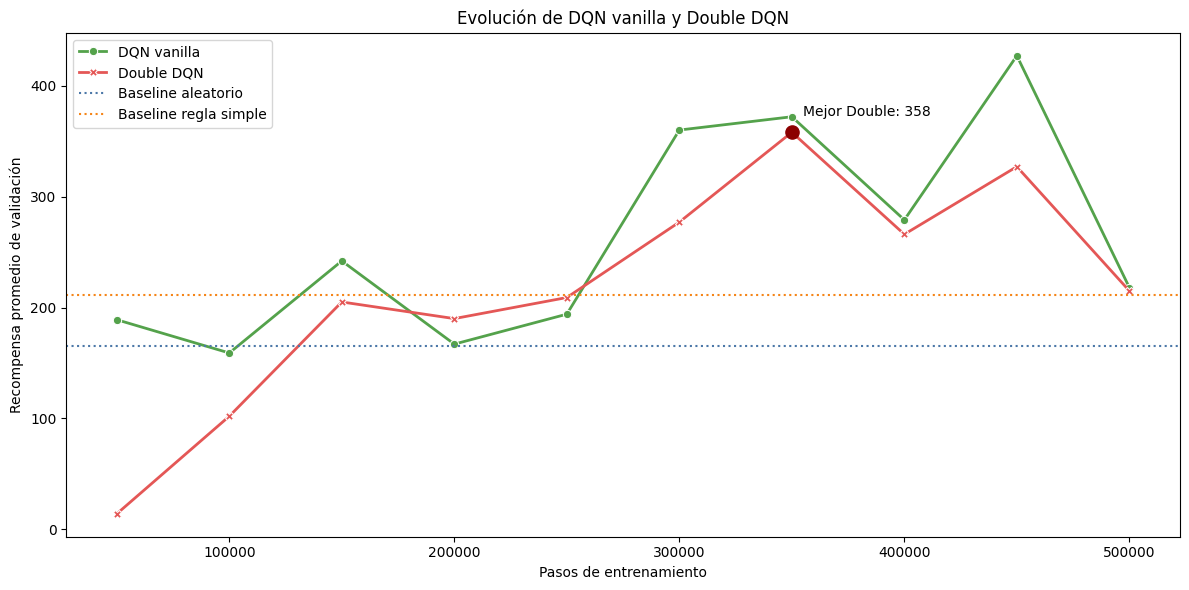

In [8]:
df_evaluaciones_vanilla = pd.read_csv(
    "../logs/entrenamientos/v1_dqn_vanilla/evaluaciones.csv"
)

df_evaluaciones_vanilla["modelo"] = "DQN vanilla"
df_evaluaciones_double["modelo"] = "Double DQN"

df_curvas_dqn = pd.concat(
    [
        df_evaluaciones_vanilla,
        df_evaluaciones_double,
    ],
    ignore_index=True,
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_curvas_dqn,
    x="paso_global",
    y="promedio",
    hue="modelo",
    style="modelo",
    markers=True,
    dashes=False,
    linewidth=2,
    palette={
        "DQN vanilla": "#54A24B",
        "Double DQN": "#E45756",
    },
)

plt.axhline(
    165.67,
    color="#4C78A8",
    linestyle=":",
    label="Baseline aleatorio",
)

plt.axhline(
    211.50,
    color="#F58518",
    linestyle=":",
    label="Baseline regla simple",
)

plt.scatter(
    mejor_evaluacion_double["paso_global"],
    mejor_evaluacion_double["promedio"],
    color="#8B0000",
    s=90,
    zorder=5,
)

plt.annotate(
    f"Mejor Double: {mejor_evaluacion_double['promedio']:.0f}",
    xy=(
        mejor_evaluacion_double["paso_global"],
        mejor_evaluacion_double["promedio"],
    ),
    xytext=(8, 12),
    textcoords="offset points",
)

plt.title("Evolución de DQN vanilla y Double DQN")
plt.xlabel("Pasos de entrenamiento")
plt.ylabel("Recompensa promedio de validación")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusiones de la iteración V2: Double DQN

Double DQN fue entrenado durante 500,000 pasos utilizando la misma arquitectura, semilla e hiperparámetros que DQN vanilla. La única diferencia fue el cálculo del target, separando la selección de la acción, realizada por la red online, de su evaluación, realizada por la red target.

El mejor checkpoint se obtuvo en el paso **350,000**, con un promedio de validación de **358 puntos** en cinco episodios.

En la evaluación formal de 30 episodios se obtuvieron los siguientes resultados:

| Métrica | Double DQN |
|---|---:|
| Promedio | 283.33 |
| Mediana | 262.50 |
| Desviación estándar | 152.25 |
| Mínimo | 105 |
| Máximo | 925 |

Double DQN superó los promedios de los agentes baseline, por lo que aprendió una política útil. Sin embargo, su promedio fue inferior a los **406.67 puntos** alcanzados por DQN vanilla.

En la comparación pareada con las mismas 30 semillas, DQN vanilla obtuvo mayor recompensa en **23 episodios**, mientras Double DQN ganó en **7 episodios**. Esto demuestra que DQN vanilla presentó un rendimiento superior en la mayoría de las condiciones iniciales.

Bajo el criterio de tomar el mejor resultado de cinco episodios, DQN vanilla obtuvo un promedio de **586.67 puntos**, frente a **476.67 puntos** de Double DQN. Aunque Double DQN produjo el mayor resultado individual del experimento hasta ahora, con **925 puntos**, este fue un episodio excepcional y no representó su desempeño habitual.

Por lo tanto, Double DQN no superó al DQN vanilla con esta configuración. Este resultado no implica que el algoritmo sea inferior en general, ya que su desempeño puede depender de la semilla, los hiperparámetros y la duración del entrenamiento.
La siguiente iteración combinará Double DQN con una arquitectura Dueling, que separa la estimación del valor del estado y la ventaja de cada acción.